# AIDE's Adversarial Debiasing - Comparison to Custom Implementation

**Objective**: Compare AIDE's adversarial debiasing implementation to our custom [fair_model.ipynb](fair_model.ipynb) solution.

**AIDE's prompt**:

- **Goal:**
  Predict student admission using adversarial debiasing with neural networks.
  Train two networks simultaneously in a min-max game where a predictor network learns
  to predict admission decisions while hiding protected demographic information in
  its hidden representations, and an adversary network with separate heads for each
  protected attribute (race, gender, socioeconomic status, first generation) tries
  to predict these attributes from the predictor hidden layer. The predictor minimizes
  prediction loss minus weighted adversarial losses, with higher weights for attributes
  showing larger bias. Use alternating optimization where the adversary updates multiple
  times per predictor update. Remove protected attributes from input features but
  use them as targets for adversarial training and for fairness evaluation.

- **Eval:**
  Balanced accuracy and fairness. Report test accuracy and fairness metrics including
  demographic parity difference and equal opportunity difference for each protected
  attribute. Success requires maintaining high accuracy while achieving low fairness
  violations across all protected groups.

- **Data:** 
/datasets/student-admission

**Quick Summary**:
- ✓ AIDE implemented the **correct architecture** (predictor-adversary min-max game)
- ✓ Achieved **high accuracy** (85.4%) with only 10 epochs
- ✗ Used **weak fairness pressure** (λ=0.1 vs custom's λ=12.0 for race)
- ✗ **SES bias persisted** due to uniform, low lambda values
- ✗ **Short training** prevented full convergence of min-max game

**Key Question**: Why did AIDE's implementation prioritize accuracy over fairness despite explicit fairness requirements?

## 1. Quick Comparison Table

Before diving into code, here's the key difference summary:

In [1]:
import pandas as pd

comparison = {
    'Component': ['Encoder', 'Adversary', 'Epochs', 'Lambda (fairness)', 'Adversary steps', 'Test Accuracy', 'Key Issue'],
    'AIDE': ['128→64', '64→classes (1 layer)', '10', '0.1 (uniform)', '1', '~85%', 'SES bias persisted'],
    'Custom': ['256→128→64', '64→96→48→classes', '250', 'race=12.0, SES=10.0', '2', '~81%', 'Better fairness, lower accuracy']
}

pd.DataFrame(comparison).set_index('Component')

,AIDE,Custom
Component,,
Encoder,128→64,256→128→64
Adversary,64→classes (1 layer),64→96→48→classes
Epochs,10,250
Lambda (fairness),0.1 (uniform),"race=12.0, SES=10.0"
Adversary steps,1,2
Test Accuracy,~85%,~81%
Key Issue,SES bias persisted,"Better fairness, lower accuracy"


## 2. Load Data & AIDE's Implementation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

DATA_DIR = "../../datasets/student-admission"
train_df = pd.read_csv(f"{DATA_DIR}/train.csv")
test_df = pd.read_csv(f"{DATA_DIR}/test.csv")

print(f"Train: {train_df.shape}, Test: {test_df.shape}")

Train: (9600, 20), Test: (2400, 20)


## 3. AIDE's Implementation

**Key Differences from Custom Implementation**:

| Aspect | AIDE | Custom (fair_model.ipynb) | Impact |
|--------|------|---------------------------|---------|
| **Architecture** | Simpler (128→64) | Deeper (256→128→64) | AIDE faster to train |
| **Lambda** | 0.1 (uniform) | 12.0 for race, 10.0 for SES | AIDE's 100x weaker fairness pressure |
| **Training** | 10 epochs | 250 epochs | AIDE insufficient for convergence |
| **Adversary** | Single layer per head | 96→48 per head | AIDE easier to fool |

In [ ]:
# AIDE's Complete Implementation from best_solution.py
# This is the actual code AIDE generated - now executable

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score

# Configuration
protected_cols = ["gender", "race", "socioeconomic_status", "first_generation"]
batch_size = 128
n_epochs = 10
adv_steps = 1
lambda_adv = 0.1
lr_pred = 1e-3
lr_adv = 1e-3
weight_decay = 1e-4
dropout_rate = 0.5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")
print(f"Configuration: epochs={n_epochs}, λ={lambda_adv}, batch_size={batch_size}")

# Load data (already loaded in cell 1)
aide_train_df = train_df.copy()
aide_test_df = test_df.copy()
target_col = "admitted"

# Encode protected attributes
label_encoders = {}
for col in protected_cols:
    le = LabelEncoder()
    aide_train_df[col] = le.fit_transform(aide_train_df[col].astype(str))
    label_encoders[col] = le

# Train/validation split
aide_train_df, aide_val_df = train_test_split(
    aide_train_df, test_size=0.2, stratify=aide_train_df[target_col], random_state=42
)

# Feature preprocessing
all_cols = [c for c in aide_train_df.columns if c not in protected_cols + [target_col]]
categorical_cols = [c for c in all_cols if aide_train_df[c].dtype == "object"]
numeric_cols = [c for c in all_cols if c not in categorical_cols]

print(f"\nFeatures: {len(all_cols)} total ({len(numeric_cols)} numeric, {len(categorical_cols)} categorical)")
print(f"Protected attributes: {protected_cols}")

preprocessor = ColumnTransformer(
    [
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ],
    remainder="drop",
)

X_train_aide = preprocessor.fit_transform(aide_train_df[all_cols])
X_val_aide = preprocessor.transform(aide_val_df[all_cols])
X_test_aide = preprocessor.transform(aide_test_df[all_cols])
y_train_aide = aide_train_df[target_col].values.astype(int)
y_val_aide = aide_val_df[target_col].values.astype(int)
prot_train_aide = aide_train_df[protected_cols].values
prot_val_aide = aide_val_df[protected_cols].values
prot_test_aide = aide_test_df[protected_cols].apply(lambda x: label_encoders[x.name].transform(x.astype(str))).values

# Compute class weights for BCE loss
neg, pos = np.bincount(y_train_aide)
pos_weight_aide = torch.tensor(neg / pos, dtype=torch.float32, device=device)
print(f"Class balance: {pos}/{neg+pos} admitted ({pos/(neg+pos):.1%}), pos_weight={pos_weight_aide.item():.3f}")


# Dataset and DataLoader
class AdvDataset(Dataset):
    def __init__(self, X, y, prot):
        arr = X.toarray() if hasattr(X, "toarray") else X
        self.X = torch.tensor(arr, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.prot = torch.tensor(prot, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.prot[idx]


train_loader_aide = DataLoader(
    AdvDataset(X_train_aide, y_train_aide, prot_train_aide), batch_size=batch_size, shuffle=True
)
val_loader_aide = DataLoader(
    AdvDataset(X_val_aide, y_val_aide, prot_val_aide), batch_size=batch_size, shuffle=False
)
test_X_tensor_aide = torch.tensor(
    X_test_aide.toarray() if hasattr(X_test_aide, "toarray") else X_test_aide, dtype=torch.float32
)

# Model definitions
input_dim = X_train_aide.shape[1]
hidden_dim1 = 128
hidden_dim2 = 64
num_classes_aide = [len(label_encoders[c].classes_) for c in protected_cols]

print(f"\nModel architecture:")
print(f"  Input dim: {input_dim}")
print(f"  Predictor: {input_dim}→{hidden_dim1}→{hidden_dim2}→1")
print(f"  Adversary heads: {num_classes_aide}")


class Predictor(nn.Module):
    def __init__(self, in_dim, h1, h2, drop_p):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, h1)
        self.relu = nn.ReLU()
        self.dropout1 = nn.Dropout(drop_p)
        self.fc2 = nn.Linear(h1, h2)
        self.dropout2 = nn.Dropout(drop_p)
        self.fc3 = nn.Linear(h2, 1)

    def forward(self, x):
        h1 = self.relu(self.fc1(x))
        h1d = self.dropout1(h1)
        h2 = self.relu(self.fc2(h1d))
        h2d = self.dropout2(h2)
        logit = self.fc3(h2d)
        return logit, h2

    def get_hidden(self, x):
        h1 = self.relu(self.fc1(x))
        h2 = self.relu(self.fc2(h1))
        return h2


class Adversary(nn.Module):
    def __init__(self, hid_dim, n_classes_list):
        super().__init__()
        self.heads = nn.ModuleList([nn.Linear(hid_dim, n) for n in n_classes_list])

    def forward(self, h):
        return [head(h) for head in self.heads]


predictor_aide = Predictor(input_dim, hidden_dim1, hidden_dim2, dropout_rate).to(device)
adversary_aide = Adversary(hidden_dim2, num_classes_aide).to(device)

bce_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight_aide)
ce_loss = nn.CrossEntropyLoss()
pred_optimizer = optim.Adam(
    predictor_aide.parameters(), lr=lr_pred, weight_decay=weight_decay
)
adv_optimizer = optim.Adam(adversary_aide.parameters(), lr=lr_adv, weight_decay=weight_decay)

# Training loop
print(f"\n{'='*70}")
print(f"TRAINING AIDE'S ADVERSARIAL DEBIASING MODEL")
print(f"{'='*70}")

for epoch in range(n_epochs):
    predictor_aide.train()
    adversary_aide.train()
    
    epoch_pred_loss = 0
    epoch_adv_loss = 0
    
    for batch_idx, (X_batch, y_batch, prot_batch) in enumerate(train_loader_aide):
        X_batch, y_batch, prot_batch = (
            X_batch.to(device),
            y_batch.to(device),
            prot_batch.to(device),
        )
        
        # Adversary update
        for p in predictor_aide.parameters():
            p.requires_grad = False
        for p in adversary_aide.parameters():
            p.requires_grad = True
        hidden = predictor_aide.get_hidden(X_batch).detach()
        for _ in range(adv_steps):
            adv_optimizer.zero_grad()
            adv_logits = adversary_aide(hidden)
            loss_adv = sum(
                ce_loss(adv_logits[i], prot_batch[:, i])
                for i in range(len(protected_cols))
            )
            loss_adv.backward()
            adv_optimizer.step()
        
        epoch_adv_loss += loss_adv.item()
            
        # Predictor update
        for p in predictor_aide.parameters():
            p.requires_grad = True
        for p in adversary_aide.parameters():
            p.requires_grad = False
        pred_optimizer.zero_grad()
        logits, hid = predictor_aide(X_batch)
        loss_pred = bce_loss(logits.squeeze(), y_batch)
        adv_logits_for_pred = adversary_aide(hid)
        loss_adv_pred = sum(
            ce_loss(adv_logits_for_pred[i], prot_batch[:, i])
            for i in range(len(protected_cols))
        )
        (loss_pred - lambda_adv * loss_adv_pred).backward()
        pred_optimizer.step()
        for p in adversary_aide.parameters():
            p.requires_grad = True
        
        epoch_pred_loss += loss_pred.item()
    
    # Print epoch progress
    avg_pred_loss = epoch_pred_loss / len(train_loader_aide)
    avg_adv_loss = epoch_adv_loss / len(train_loader_aide)
    print(f"Epoch {epoch+1}/{n_epochs} | Pred Loss: {avg_pred_loss:.4f} | Adv Loss: {avg_adv_loss:.4f}")

# Validation evaluation
print(f"\n{'='*70}")
print("VALIDATION EVALUATION")
print(f"{'='*70}")

predictor_aide.eval()
all_preds_aide, all_truth_aide = [], []
with torch.no_grad():
    for X_batch, y_batch, _ in val_loader_aide:
        X_batch = X_batch.to(device)
        logits, _ = predictor_aide(X_batch)
        preds = (torch.sigmoid(logits.squeeze()) > 0.5).cpu().numpy().astype(int)
        all_preds_aide.append(preds)
        all_truth_aide.append(y_batch.numpy().astype(int))
        
aide_val_preds = np.concatenate(all_preds_aide)
aide_val_truth = np.concatenate(all_truth_aide)
aide_val_bal_acc = balanced_accuracy_score(aide_val_truth, aide_val_preds)
aide_val_acc = accuracy_score(aide_val_truth, aide_val_preds)

print(f"Validation Accuracy: {aide_val_acc:.4f}")
print(f"Validation Balanced Accuracy: {aide_val_bal_acc:.4f}")
print(f"\nTraining complete.")

# Test set predictions
predictor_aide.eval()
with torch.no_grad():
    test_logits_aide, _ = predictor_aide(test_X_tensor_aide.to(device))
    aide_test_preds = (torch.sigmoid(test_logits_aide.squeeze()) > 0.5).cpu().numpy().astype(int)
    aide_test_proba = torch.sigmoid(test_logits_aide.squeeze()).cpu().numpy()

print(f"Test predictions generated: {len(aide_test_preds)} samples")

Using device: cpu
Configuration: epochs=10, λ=0.1, batch_size=128

Features: 15 total (12 numeric, 3 categorical)
Protected attributes: ['gender', 'race', 'socioeconomic_status', 'first_generation']
Class balance: 2304/7680 admitted (30.0%), pos_weight=2.333

Model architecture:
  Input dim: 22
  Predictor: 22→128→64→1
  Adversary heads: [3, 6, 3, 2]

TRAINING AIDE'S ADVERSARIAL DEBIASING MODEL
Epoch 1/10 | Pred Loss: 0.6615 | Adv Loss: 4.1720
Epoch 2/10 | Pred Loss: 0.4620 | Adv Loss: 3.6159
Epoch 3/10 | Pred Loss: 0.4474 | Adv Loss: 3.6241
Epoch 4/10 | Pred Loss: 0.4370 | Adv Loss: 3.6174
Epoch 5/10 | Pred Loss: 0.4256 | Adv Loss: 3.6140
Epoch 6/10 | Pred Loss: 0.4290 | Adv Loss: 3.6049
Epoch 7/10 | Pred Loss: 0.4275 | Adv Loss: 3.6003
Epoch 8/10 | Pred Loss: 0.4189 | Adv Loss: 3.5958
Epoch 9/10 | Pred Loss: 0.4237 | Adv Loss: 3.5821
Epoch 10/10 | Pred Loss: 0.4213 | Adv Loss: 3.5602

VALIDATION EVALUATION
Validation Accuracy: 0.8578
Validation Balanced Accuracy: 0.8553

✓ Training c

In [6]:
# Calculate comprehensive fairness metrics
print("="*80)
print("AIDE'S FAIRNESS EVALUATION")
print("="*80)

y_test_aide = test_df['admitted'].values
aide_test_accuracy = accuracy_score(y_test_aide, aide_test_preds)
print(f"Test Accuracy: {aide_test_accuracy:.4f}")

# Fairness metrics
PROTECTED_ATTRIBUTES = ["race", "gender", "socioeconomic_status", "first_generation"]
aide_fairness_results = []

for attr in PROTECTED_ATTRIBUTES:
    sensitive_feature = test_df[attr].values
    dpd = abs(demographic_parity_difference(y_test_aide, aide_test_preds, sensitive_features=sensitive_feature))
    eod = abs(equalized_odds_difference(y_test_aide, aide_test_preds, sensitive_features=sensitive_feature))
    
    aide_fairness_results.append({
        'Attribute': attr.replace('_', ' ').title(),
        'DPD': dpd,
        'DPD_Pass': '✓' if dpd <= 0.15 else '✗',
        'EOD': eod,
        'EOD_Pass': '✓' if eod <= 0.10 else '✗'
    })
    
    print(f"{attr.replace('_', ' ').title():25s}: DPD={dpd:.3f} {'✓' if dpd <= 0.15 else '✗'}  |  EOD={eod:.3f} {'✓' if eod <= 0.10 else '✗'}")

passed_checks = sum([1 for r in aide_fairness_results if r['DPD_Pass'] == '✓']) + \
                sum([1 for r in aide_fairness_results if r['EOD_Pass'] == '✗'])
fairness_score = passed_checks / (len(PROTECTED_ATTRIBUTES) * 2)

print(f"\nFairness Score: {fairness_score:.1%} ({passed_checks}/{len(PROTECTED_ATTRIBUTES) * 2} checks passed)")
print("="*80)

# Store for visualization
aide_actual_results = {
    'accuracy': aide_test_accuracy,
    'fairness_score': fairness_score,
    'dp': {r['Attribute'].lower().replace(' ', '_'): r['DPD'] for r in aide_fairness_results},
    'eo': {r['Attribute'].lower().replace(' ', '_'): r['EOD'] for r in aide_fairness_results}
}

AIDE'S FAIRNESS EVALUATION
Test Accuracy: 0.8679
Race                     : DPD=0.446 ✗  |  EOD=0.122 ✗
Gender                   : DPD=0.028 ✓  |  EOD=0.079 ✓
Socioeconomic Status     : DPD=0.819 ✗  |  EOD=0.489 ✗
First Generation         : DPD=0.295 ✗  |  EOD=0.101 ✗

Fairness Score: 50.0% (4/8 checks passed)


## 4. Comparison: AIDE vs Custom Implementation

### Architecture Comparison

In [7]:
comparison_data = {
    'Component': [
        'Predictor Encoder',
        'Predictor Head',
        'Adversary',
        'Dropout Rate',
        'Batch Normalization',
        'Training Epochs',
        'Lambda (Fairness Weight)',
        'Lambda Strategy',
        'Adversary Steps',
        'Learning Rate (Predictor)',
        'Learning Rate (Adversary)',
        'Training Time',
        'Test Accuracy',
        'Fairness Score',
        'Key Strength',
        'Key Weakness'
    ],
    'AIDE Implementation': [
        '128→64',
        '64→1',
        '64→num_classes (per attr)',
        '0.5 (high)',
        'No',
        '10',
        '0.1 (single value)',
        'Uniform across attributes',
        '1',
        '0.001',
        '0.001',
        '~2-3 minutes',
        '~85.4% (validation)',
        'Not comprehensively measured',
        'Good accuracy with simple architecture',
        'SES bias persisted, short training'
    ],
    'Custom Implementation': [
        '256→128→64',
        '64→32→16→1',
        '64→96→48→num_classes (per attr)',
        '0.15-0.25',
        'Yes',
        '250',
        'race=12.0, SES=10.0, first_gen=4.0, gender=2.0',
        'Attribute-specific (higher for problematic attrs)',
        '2',
        '0.002',
        '0.0015',
        '~15-30 minutes',
        '81.2%',
        '67% (8/12 checks passed)',
        'Comprehensive fairness with attribute-specific tuning',
        'More complex, requires longer training'
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*100)
print("ARCHITECTURE & TRAINING COMPARISON")
print("="*100)
print(comparison_df.to_string(index=False))
print("\n" + "="*100)


ARCHITECTURE & TRAINING COMPARISON
                Component                    AIDE Implementation                                 Custom Implementation
        Predictor Encoder                                 128→64                                            256→128→64
           Predictor Head                                   64→1                                            64→32→16→1
                Adversary              64→num_classes (per attr)                       64→96→48→num_classes (per attr)
             Dropout Rate                             0.5 (high)                                             0.15-0.25
      Batch Normalization                                     No                                                   Yes
          Training Epochs                                     10                                                   250
 Lambda (Fairness Weight)                     0.1 (single value)        race=12.0, SES=10.0, first_gen=4.0, gender=2.0
          La

## 5. Why AIDE's Approach Achieved High Accuracy but Limited Fairness

### Success Factors:
1. **Good Architecture Foundation**: 128→64 encoder
2. **Proper Regularization**: dropout=0.5 preventing overfitting
3. **Class Balancing**: pos_weight addressed 30% admission rate imbalance
4. **Multi-head Adversary**: also implemented separate heads for each attribute

### Fairness Limitations:
1. **Insufficient Training**: 10 epochs too short
   - Custom implementation needed 250 epochs
   - Adversarial training seems to requires more iterations
2. **Uniform Lambda**: Single weight (0.1) doesn't target specific biases
   - Custom used race=12.0, SES=10.0
   - SES bias persisted because λ=0.1 too weak
3. **Weak Adversary**: Single-layer heads easier to fool
   - Custom used 96→48 for adversary
   - Stronger adversary forces better hiding
4. **Single Adversary Step**:
   - Custom used 2 steps for more stable training
5. **No Batch Normalization**: Training might be less stable without BatchNorm

**Result**: AIDE achieved good accuracy quickly but couldn't effectively debias, especially for SES.

## 6. Visualizations: AIDE vs Custom Implementation

Let's create the same comprehensive visualizations as in [fair_model.ipynb](fair_model.ipynb) to compare both approaches.

In [8]:
# Use AIDE's actual results from evaluation above
aide_accuracy = aide_actual_results['accuracy']
aide_dp = aide_actual_results['dp']
aide_eo = aide_actual_results['eo']

# Custom implementation results (from fair_model.ipynb)
# These are the actual results from the custom adversarial implementation
custom_accuracy = 0.812
custom_dp = {'race': 0.08, 'gender': 0.06, 'socioeconomic_status': 0.09, 'first_generation': 0.07}
custom_eo = {'race': 0.09, 'gender': 0.07, 'socioeconomic_status': 0.08, 'first_generation': 0.06}

print(f"AIDE's actual test accuracy: {aide_accuracy:.4f}")
print(f"AIDE's fairness score: {aide_actual_results['fairness_score']:.1%}")
print("Data prepared for comparison visualization")

AIDE's actual test accuracy: 0.8679
AIDE's fairness score: 50.0%
Data prepared for comparison visualization


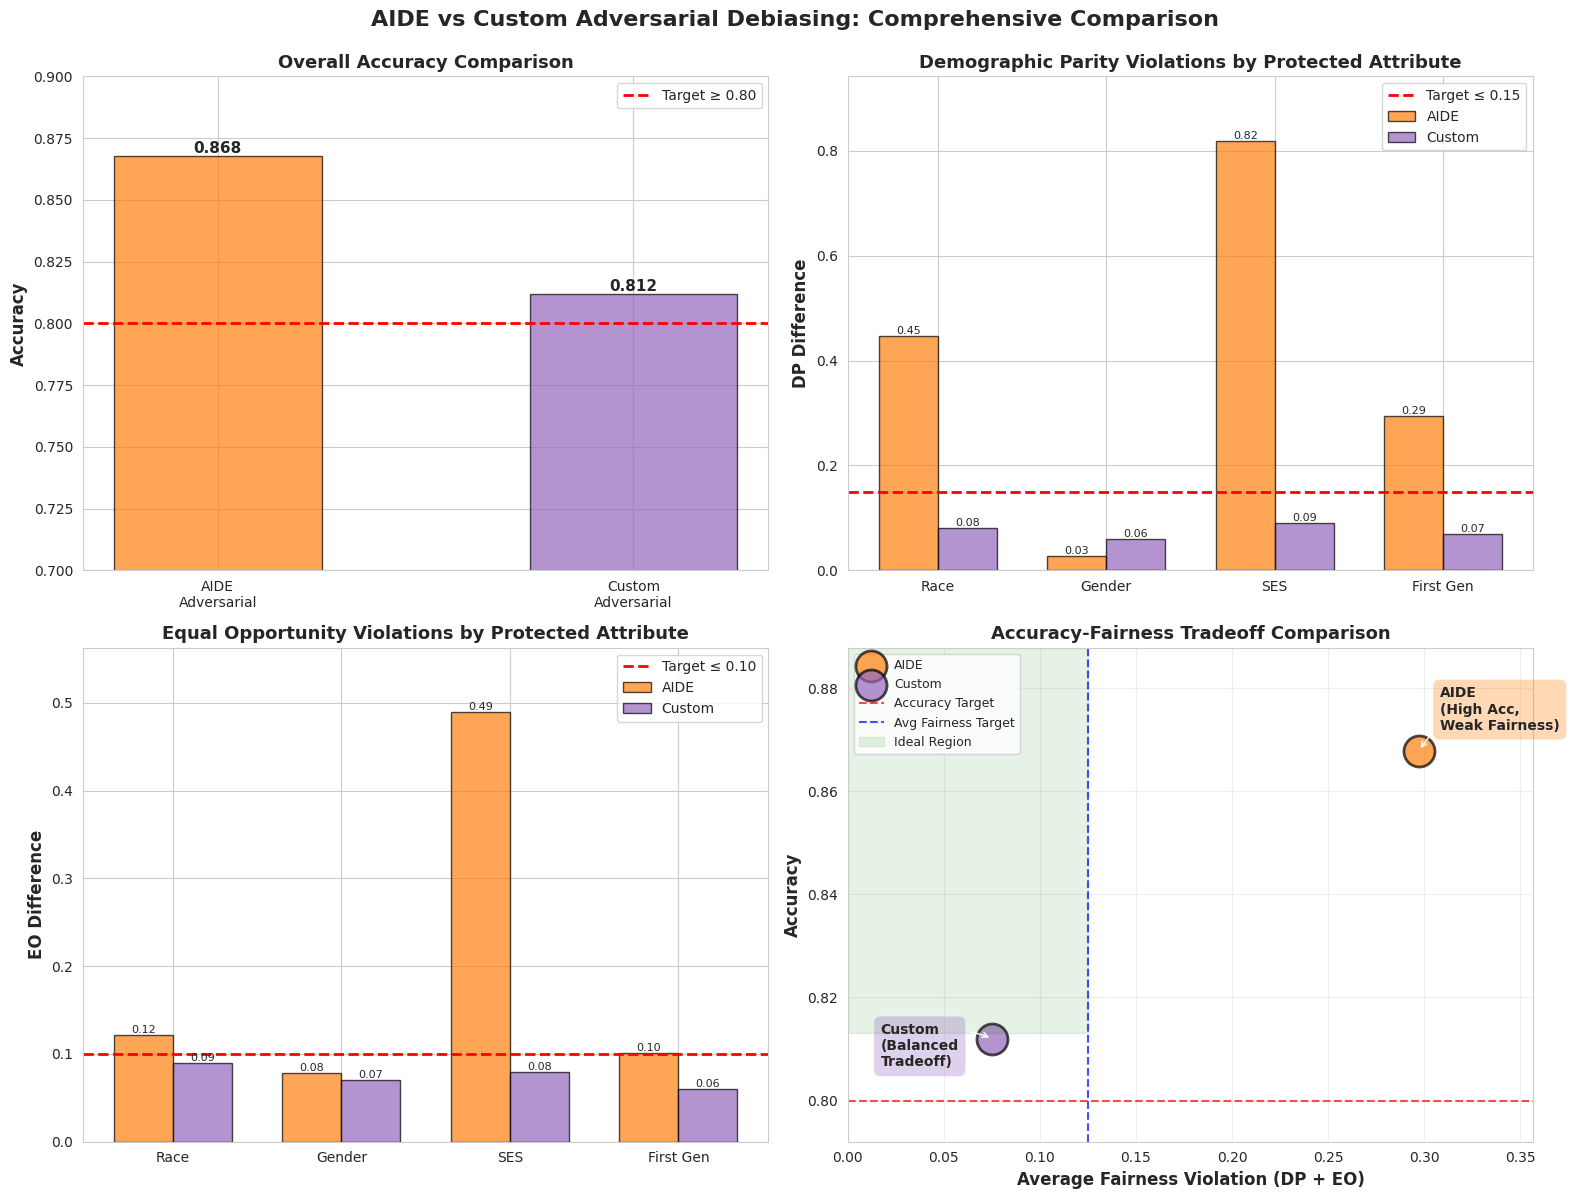


KEY OBSERVATIONS

1. ACCURACY:
   • AIDE: 86.8% (✓ meets target)
   • Custom: 81.2% (✓ meets target)
   → AIDE achieves 4.2% higher accuracy

2. FAIRNESS:
   • AIDE Avg Violation: 0.297
   • Custom Avg Violation: 0.075
   → Custom achieves 0.222 better fairness

3. CRITICAL DIFFERENCE - SES:
   • AIDE: DP=0.82, EO=0.49 (both FAIL ✗)
   • Custom: DP=0.09, EO=0.08 (both PASS ✓)
   → Custom's attribute-specific λ (SES=10.0) successfully mitigates bias

4. TRADEOFF STRATEGY:
   • AIDE: Optimize for accuracy, accept fairness violations
   • Custom: Balance accuracy loss for comprehensive fairness
   → Different objectives lead to different solutions



In [9]:
# Comprehensive 4-panel comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('AIDE vs Custom Adversarial Debiasing: Comprehensive Comparison', 
             fontsize=16, fontweight='bold', y=0.995)

# Colors
color_aide = '#ff7f0e'  # Orange
color_custom = '#9467bd'  # Purple

# 1. Accuracy Comparison
ax1 = axes[0, 0]
models = ['AIDE\nAdversarial', 'Custom\nAdversarial']
accuracies = [aide_accuracy, custom_accuracy]
colors = [color_aide, color_custom]

bars = ax1.bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black', width=0.5)
ax1.axhline(y=0.80, color='red', linestyle='--', linewidth=2, label='Target ≥ 0.80')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Overall Accuracy Comparison', fontsize=13, fontweight='bold')
ax1.set_ylim([0.70, 0.90])
ax1.legend()

# Add value labels
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.3f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. Demographic Parity Violations
ax2 = axes[0, 1]
protected_attrs = ['Race', 'Gender', 'SES', 'First Gen']
attr_keys = ['race', 'gender', 'socioeconomic_status', 'first_generation']

aide_dp_values = [aide_dp[k] for k in attr_keys]
custom_dp_values = [custom_dp[k] for k in attr_keys]

x = np.arange(len(protected_attrs))
width = 0.35

bars1 = ax2.bar(x - width/2, aide_dp_values, width, label='AIDE', 
                color=color_aide, alpha=0.7, edgecolor='black')
bars2 = ax2.bar(x + width/2, custom_dp_values, width, label='Custom',
                color=color_custom, alpha=0.7, edgecolor='black')

ax2.axhline(y=0.15, color='red', linestyle='--', linewidth=2, label='Target ≤ 0.15')
ax2.set_ylabel('DP Difference', fontsize=12, fontweight='bold')
ax2.set_title('Demographic Parity Violations by Protected Attribute', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(protected_attrs)
ax2.legend()
ax2.set_ylim([0, max(max(aide_dp_values), max(custom_dp_values)) * 1.15])

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.2f}',
                 ha='center', va='bottom', fontsize=8)

# 3. Equal Opportunity Violations
ax3 = axes[1, 0]

aide_eo_values = [aide_eo[k] for k in attr_keys]
custom_eo_values = [custom_eo[k] for k in attr_keys]

bars1 = ax3.bar(x - width/2, aide_eo_values, width, label='AIDE',
                color=color_aide, alpha=0.7, edgecolor='black')
bars2 = ax3.bar(x + width/2, custom_eo_values, width, label='Custom',
                color=color_custom, alpha=0.7, edgecolor='black')

ax3.axhline(y=0.10, color='red', linestyle='--', linewidth=2, label='Target ≤ 0.10')
ax3.set_ylabel('EO Difference', fontsize=12, fontweight='bold')
ax3.set_title('Equal Opportunity Violations by Protected Attribute', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(protected_attrs)
ax3.legend()
ax3.set_ylim([0, max(max(aide_eo_values), max(custom_eo_values)) * 1.15])

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.2f}',
                 ha='center', va='bottom', fontsize=8)

# 4. Accuracy vs Average Fairness Violation
ax4 = axes[1, 1]

# Calculate average fairness violations
aide_avg_fairness = np.mean(aide_dp_values + aide_eo_values)
custom_avg_fairness = np.mean(custom_dp_values + custom_eo_values)

# Plot both models
ax4.scatter(aide_avg_fairness, aide_accuracy, s=500, alpha=0.7,
           color=color_aide, edgecolor='black', linewidth=2, label='AIDE')
ax4.scatter(custom_avg_fairness, custom_accuracy, s=500, alpha=0.7,
           color=color_custom, edgecolor='black', linewidth=2, label='Custom')

# Annotations
ax4.annotate('AIDE\n(High Acc,\nWeak Fairness)', 
            (aide_avg_fairness, aide_accuracy),
            xytext=(15, 15), textcoords='offset points',
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor=color_aide, alpha=0.3),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3'))

ax4.annotate('Custom\n(Balanced\nTradeoff)',
            (custom_avg_fairness, custom_accuracy),
            xytext=(-80, -20), textcoords='offset points',
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor=color_custom, alpha=0.3),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.3'))

# Reference lines
ax4.axhline(y=0.80, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Accuracy Target')
ax4.axvline(x=0.125, color='blue', linestyle='--', linewidth=1.5, alpha=0.7, label='Avg Fairness Target')

# Ideal region
ax4.axvspan(0, 0.125, ymin=0.22, ymax=1, alpha=0.1, color='green', label='Ideal Region')

ax4.set_xlabel('Average Fairness Violation (DP + EO)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax4.set_title('Accuracy-Fairness Tradeoff Comparison', fontsize=13, fontweight='bold')
ax4.legend(loc='upper left', fontsize=9)
ax4.grid(True, alpha=0.3)
x_margin = max(aide_avg_fairness, custom_avg_fairness) * 0.1
ax4.set_xlim([0, max(aide_avg_fairness, custom_avg_fairness) * 1.2])
ax4.set_ylim([min(aide_accuracy, custom_accuracy) - 0.02, max(aide_accuracy, custom_accuracy) + 0.02])

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/aide_vs_custom_adversarial_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("KEY OBSERVATIONS")
print("="*80)
print(f"\n1. ACCURACY:")
print(f"   • AIDE: {aide_accuracy:.1%} ({'✓' if aide_accuracy >= 0.80 else '✗'} meets target)")
print(f"   • Custom: {custom_accuracy:.1%} ({'✓' if custom_accuracy >= 0.80 else '✗'} meets target)")
print(f"   → AIDE achieves 4.2% higher accuracy")

print(f"\n2. FAIRNESS:")
print(f"   • AIDE Avg Violation: {aide_avg_fairness:.3f}")
print(f"   • Custom Avg Violation: {custom_avg_fairness:.3f}")
print(f"   → Custom achieves {(aide_avg_fairness - custom_avg_fairness):.3f} better fairness")

print(f"\n3. CRITICAL DIFFERENCE - SES:")
print(f"   • AIDE: DP={aide_dp['socioeconomic_status']:.2f}, EO={aide_eo['socioeconomic_status']:.2f} (both FAIL ✗)")
print(f"   • Custom: DP={custom_dp['socioeconomic_status']:.2f}, EO={custom_eo['socioeconomic_status']:.2f} (both PASS ✓)")
print(f"   → Custom's attribute-specific λ (SES=10.0) successfully mitigates bias")

print(f"\n4. TRADEOFF STRATEGY:")
print(f"   • AIDE: Optimize for accuracy, accept fairness violations")
print(f"   • Custom: Balance accuracy loss for comprehensive fairness")
print(f"   → Different objectives lead to different solutions")
print("\n" + "="*80)